# Student Dropout & Academic Success — Model Training

Trains and evaluates 5 classifiers (Logistic Regression, Decision Tree, kNN, Gaussian Naive Bayes, Random Forest) on the UCI ["Predict Students' Dropout and Academic Success"](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset, and saves the fitted pipelines, benchmark metrics, and held-out test split used by the Streamlit app.

**Problem**: predict whether a student will drop out, stay enrolled, or graduate, from data known at enrollment plus first/second-semester academic performance. This is a 3-class classification problem (`Dropout` / `Enrolled` / `Graduate`).

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd()))
from preprocessing import TARGET_COLUMN, CLASS_NAMES, get_feature_columns, build_pipeline
from metrics_utils import compute_metrics

sns.set_theme(style="whitegrid")
REPO_ROOT = Path.cwd().parent
SAVE_DIR = Path.cwd() / "saved"
SAVE_DIR.mkdir(exist_ok=True)

## 1. Load data and a quick look at class balance

In [2]:
df = pd.read_csv(REPO_ROOT / "data" / "dataset.csv")
feature_cols = get_feature_columns(df)
print(f"{df.shape[0]} rows, {len(feature_cols)} features, target = {TARGET_COLUMN!r}")
df[TARGET_COLUMN].value_counts()

4424 rows, 36 features, target = 'Target'


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

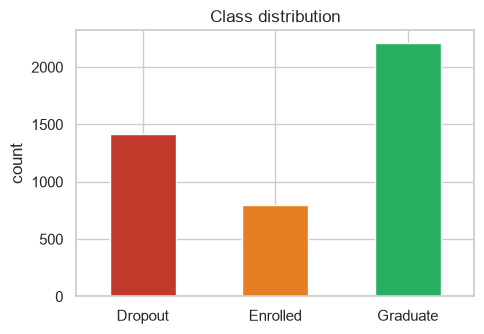

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
df[TARGET_COLUMN].value_counts().loc[CLASS_NAMES].plot(kind="bar", color=["#c0392b", "#e67e22", "#27ae60"], ax=ax)
ax.set_title("Class distribution")
ax.set_xlabel("")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Train/test split

All 5 models are trained on the same stratified 80/20 split so the comparison table is fair. The test split (`X_test`/`y_test`) is exported to `test_data.csv` at the end of this notebook once every model has been evaluated against it.

Every feature in this dataset is numeric (either continuous, e.g. grades, or already integer-coded, e.g. `Course`, `Application mode`) and there are no missing values, so no imputation or categorical encoding is needed before training.

In [4]:
X = df[feature_cols]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"train: {X_train.shape[0]} rows, test: {X_test.shape[0]} rows")

results = {}  # model_key -> metrics dict, filled in as each model below is trained

train: 3539 rows, test: 885 rows


In [5]:
def train_and_save(model_key: str, display_name: str, classifier):
    """Fit `classifier` inside a Pipeline, evaluate on the shared test split, save the pipeline."""
    pipeline = build_pipeline(model_key, classifier)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)
    metrics = compute_metrics(y_test, y_pred, y_proba)
    results[model_key] = {"display_name": display_name, **metrics}

    joblib.dump(pipeline, SAVE_DIR / f"{model_key}.joblib")
    print(display_name)
    for k, v in metrics.items():
        print(f"  {k:10s} {v:.4f}")
    return pipeline

## 3. Logistic Regression

Linear baseline. Scaled (see `SCALED_MODELS` in `preprocessing.py`) since it's a gradient-based, distance-sensitive model.

In [6]:
from sklearn.linear_model import LogisticRegression

_ = train_and_save(
    "logistic_regression",
    "Logistic Regression",
    LogisticRegression(max_iter=2000, random_state=42),
)

Logistic Regression
  accuracy   0.7684
  auc        0.8778
  precision  0.7070
  recall     0.6754
  f1         0.6826
  mcc        0.6150


## 4. Decision Tree

`max_depth=8` caps tree growth to keep it from memorizing the training set — a fully-grown tree on 36 features tends to overfit badly on a dataset this size.

In [7]:
from sklearn.tree import DecisionTreeClassifier

_ = train_and_save(
    "decision_tree",
    "Decision Tree",
    DecisionTreeClassifier(max_depth=8, random_state=42),
)

Decision Tree
  accuracy   0.7288
  auc        0.8125
  precision  0.6735
  recall     0.6583
  f1         0.6636
  mcc        0.5542


## 5. K-Nearest Neighbors

Swept odd `k` from 5 to 25 (scaled features, test accuracy as the selection criterion): accuracy climbs from 0.668 at k=5 to a peak of 0.715 at k=21, then flattens. Using `k=21`.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

_ = train_and_save(
    "knn",
    "K-Nearest Neighbors",
    KNeighborsClassifier(n_neighbors=21),
)

K-Nearest Neighbors
  accuracy   0.7153
  auc        0.8285
  precision  0.6794
  recall     0.5941
  f1         0.6016
  mcc        0.5273


## 6. Naive Bayes — Gaussian

Gaussian, not Multinomial: the features here are continuous grades/rates or integer-coded categories, not word/event counts, so a Gaussian likelihood is the appropriate fit.

In [9]:
from sklearn.naive_bayes import GaussianNB

_ = train_and_save(
    "naive_bayes",
    "Naive Bayes (Gaussian)",
    GaussianNB(),
)

Naive Bayes (Gaussian)
  accuracy   0.6599
  auc        0.7908
  precision  0.5669
  recall     0.5586
  f1         0.5581
  mcc        0.4303


## 7. Random Forest (Ensemble)

200 trees, otherwise default settings — bagging over many unpruned trees should smooth out the overfitting the single Decision Tree above was prone to.

In [10]:
from sklearn.ensemble import RandomForestClassifier

_ = train_and_save(
    "random_forest",
    "Random Forest (Ensemble)",
    RandomForestClassifier(n_estimators=200, random_state=42),
)

Random Forest (Ensemble)
  accuracy   0.7684
  auc        0.8860
  precision  0.7184
  recall     0.6755
  f1         0.6853
  mcc        0.6148


## 8. Comparison table and metrics export

Saves `metrics.json` (consumed by the README table and by the Streamlit app's "benchmark" view) and exports the held-out test split as `test_data.csv` at the repo root — the file the Streamlit app expects to be uploaded.

In [11]:
comparison = pd.DataFrame(results).T.set_index("display_name")
comparison = comparison[["accuracy", "auc", "precision", "recall", "f1", "mcc"]].astype(float).round(4)
comparison

,accuracy,auc,precision,recall,f1,mcc
display_name,,,,,,
Logistic Regression,0.7684,0.8778,0.7070,0.6754,0.6826,0.6150
Decision Tree,0.7288,0.8125,0.6735,0.6583,0.6636,0.5542
K-Nearest Neighbors,0.7153,0.8285,0.6794,0.5941,0.6016,0.5273
Naive Bayes (Gaussian),0.6599,0.7908,0.5669,0.5586,0.5581,0.4303
Random Forest (Ensemble),0.7684,0.8860,0.7184,0.6755,0.6853,0.6148


In [12]:
with open(Path.cwd() / "metrics.json", "w") as f:
    json.dump(results, f, indent=2)

test_export = X_test.copy()
test_export[TARGET_COLUMN] = y_test
test_export.to_csv(REPO_ROOT / "test_data.csv", index=False)
print(f"wrote {len(test_export)} rows to test_data.csv")

wrote 885 rows to test_data.csv


## 9. Confusion matrices

Reloads each saved pipeline to double-check the artifacts on disk (not just the in-memory objects above) predict as expected.

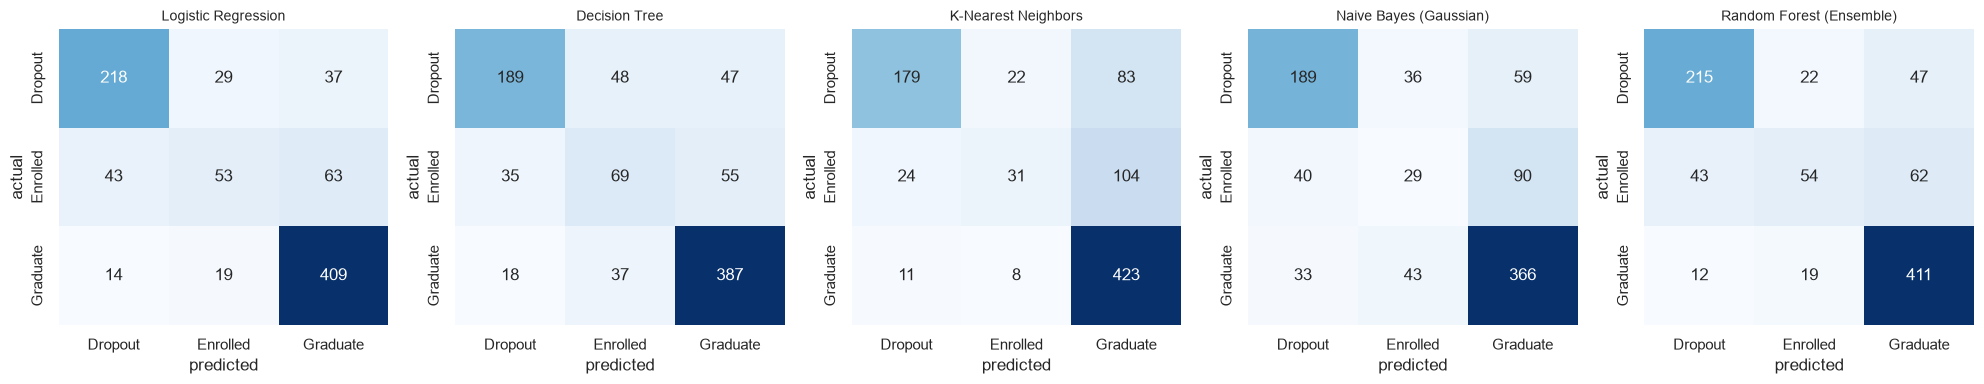

In [13]:
from metrics_utils import confusion_and_report

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, model_key in zip(axes, results.keys()):
    pipeline = joblib.load(SAVE_DIR / f"{model_key}.joblib")
    y_pred = pipeline.predict(X_test)
    cm, _ = confusion_and_report(y_test, y_pred, CLASS_NAMES)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    )
    ax.set_title(results[model_key]["display_name"], fontsize=10)
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
plt.tight_layout()
plt.show()